In [1]:
import pandas as pd
import torch
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("study.csv")

In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   study_hours  50 non-null     float64
 1   grade        50 non-null     float64
dtypes: float64(2)
memory usage: 932.0 bytes


In [52]:
X = torch.tensor(df['study_hours'].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df['grade'].values, dtype=torch.float32).unsqueeze(1)

In [53]:
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

In [54]:
X_train.shape, y_train.shape

(torch.Size([40, 1]), torch.Size([40, 1]))

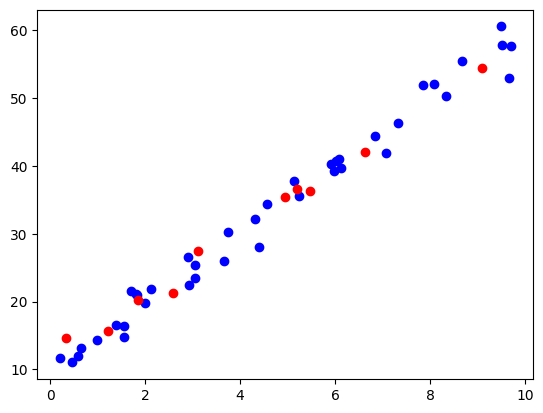

In [26]:
plt.scatter(X_train, y_train, color='blue', label='Train Data')
plt.scatter(X_test, y_test, color='red', label='Test Data')

In [27]:
import torch.nn as nn

class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_layer = nn.Linear(in_features=1, out_features=1)

    def forward(self, x):
        return self.linear_layer(x)

In [28]:
torch.manual_seed(42)
model = LinearRegressionModel()

In [29]:
model

LinearRegressionModel(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [30]:
model.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
             ('linear_layer.bias', tensor([0.8300]))])

In [31]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(params = model.parameters(), lr=0.001)

In [41]:
epochs = 1000

In [42]:
for epoch in range(epochs):
    
    model.train()
    
    y_pred = model(X_train)

    loss = loss_fn(y_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.inference_mode():
        test_pred = model(X_test)
        test_loss = loss_fn(test_pred, y_test)

        if epoch % 10 == 0:
            print(f"Epoch: {epoch} | Loss: {loss:.4f} | Test Loss: {test_loss:.4f}")

Epoch: 0 | Loss: 3.6297 | Test Loss: 2.0620
Epoch: 10 | Loss: 3.6297 | Test Loss: 2.0620
Epoch: 20 | Loss: 3.6297 | Test Loss: 2.0620
Epoch: 30 | Loss: 3.6297 | Test Loss: 2.0620
Epoch: 40 | Loss: 3.6297 | Test Loss: 2.0620
Epoch: 50 | Loss: 3.6297 | Test Loss: 2.0620
Epoch: 60 | Loss: 3.6297 | Test Loss: 2.0620
Epoch: 70 | Loss: 3.6297 | Test Loss: 2.0620
Epoch: 80 | Loss: 3.6297 | Test Loss: 2.0620
Epoch: 90 | Loss: 3.6297 | Test Loss: 2.0620
Epoch: 100 | Loss: 3.6297 | Test Loss: 2.0620
Epoch: 110 | Loss: 3.6297 | Test Loss: 2.0620
Epoch: 120 | Loss: 3.6297 | Test Loss: 2.0620
Epoch: 130 | Loss: 3.6297 | Test Loss: 2.0620
Epoch: 140 | Loss: 3.6297 | Test Loss: 2.0620
Epoch: 150 | Loss: 3.6297 | Test Loss: 2.0620
Epoch: 160 | Loss: 3.6297 | Test Loss: 2.0620
Epoch: 170 | Loss: 3.6297 | Test Loss: 2.0620
Epoch: 180 | Loss: 3.6297 | Test Loss: 2.0620
Epoch: 190 | Loss: 3.6297 | Test Loss: 2.0620
Epoch: 200 | Loss: 3.6297 | Test Loss: 2.0620
Epoch: 210 | Loss: 3.6297 | Test Loss: 2.0620

In [43]:
model.eval()
with torch.inference_mode():
    y_pred = model(X_test)

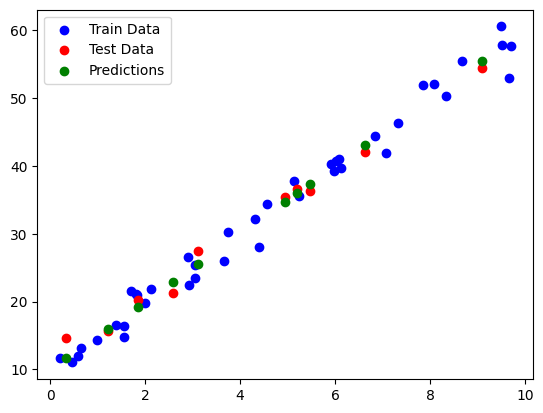

In [44]:
plt.scatter(X_train, y_train, color='blue', label='Train Data')
plt.scatter(X_test, y_test, color='red', label='Test Data')
plt.scatter(X_test, y_pred, color='green', label='Predictions')
plt.legend()